In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
employees = pd.read_csv("Employees.csv")
attendance = pd.read_csv("Attendance.csv")
performance = pd.read_csv("Performance.csv")
engagement = pd.read_csv("Employee_Engagement.csv")

In [3]:
print("Employees:", employees.shape)
print("Attendance:", attendance.shape)
print("Performance:", performance.shape)
print("Engagement:", engagement.shape)

Employees: (5008, 14)
Attendance: (176071, 8)
Performance: (5010, 9)
Engagement: (5010, 8)


In [4]:
print("Employees:")
print(employees.columns.tolist())

Employees:
['Employee_ID', 'Employee_Name', 'Gender', 'Age', 'Department', 'Designation', 'Joining_Date', 'Experience_Years', 'Education', 'Employment_Type', 'Location', 'Manager_ID', 'Salary', 'Employment_Status']


In [5]:
print("\nAttendance:")
print(attendance.columns.tolist())


Attendance:
['Attendance_ID', 'Employee_ID', 'Date', 'Status', 'Work_Hours', 'Overtime_Hours', 'Late_Minutes', 'Remote_Work']


In [6]:
print("\nPerformance:")
print(performance.columns.tolist())


Performance:
['Review_ID', 'Employee_ID', 'Review_Date', 'Performance_Score', 'Productivity_Score', 'Quality_Score', 'Manager_Rating', 'Target_Achievement', 'Promotion_Eligible']


In [7]:
print("\nEngagement:")
print(engagement.columns.tolist())


Engagement:
['Employee_ID', 'Survey_Date', 'Job_Satisfaction', 'Work_Life_Balance', 'Manager_Satisfaction', 'Career_Growth', 'Environment_Satisfaction', 'Engagement_Score']


In [8]:
attendance_ml = (
    attendance
    .groupby("Employee_ID")
    .agg(
        Attendance_Records=("Attendance_ID", "count"),
        Present_Records=("Status", lambda x: (x == "Present").sum()),
        Average_Overtime=("Overtime_Hours", "mean")
    )
    .reset_index()
)

attendance_ml["Attendance_Percentage"] = (
    attendance_ml["Present_Records"]
    / attendance_ml["Attendance_Records"]
) * 100

attendance_ml[
    ["Attendance_Percentage", "Average_Overtime"]
] = attendance_ml[
    ["Attendance_Percentage", "Average_Overtime"]
].round(2)

attendance_ml.head()

,Employee_ID,Attendance_Records,Present_Records,Average_Overtime,Attendance_Percentage
0,E00001,30,20,0.52,66.67
1,E00002,40,38,0.73,95.00
2,E00003,40,33,0.38,82.50
3,E00004,40,36,0.34,90.00
4,E00006,40,34,0.20,85.00


In [9]:
# performance:
performance_ml = (
    performance
    .groupby("Employee_ID")
    .agg(
        Performance_Score=("Performance_Score", "mean")
    )
    .reset_index()
)

performance_ml["Performance_Score"] = (
    performance_ml["Performance_Score"].round(2)
)

performance_ml.head()

,Employee_ID,Performance_Score
0,E00009,77.2
1,E00010,52.8
2,E00011,80.7
3,E00012,75.9
4,E00013,82.7


In [10]:
engagement_ml = (
    engagement
    .groupby("Employee_ID")
    .agg(
        Job_Satisfaction=("Job_Satisfaction", "mean"),
        Work_Life_Balance=("Work_Life_Balance", "mean"),
        Career_Growth=("Career_Growth", "mean"),
        Manager_Satisfaction=("Manager_Satisfaction", "mean")
    )
    .reset_index()
)

engagement_ml[
    [
        "Job_Satisfaction",
        "Work_Life_Balance",
        "Career_Growth",
        "Manager_Satisfaction"
    ]
] = engagement_ml[
    [
        "Job_Satisfaction",
        "Work_Life_Balance",
        "Career_Growth",
        "Manager_Satisfaction"
    ]
].round(2)

engagement_ml.head()

,Employee_ID,Job_Satisfaction,Work_Life_Balance,Career_Growth,Manager_Satisfaction
0,E00009,69.4,90.0,87.0,88.4
1,E00010,78.1,70.8,73.4,58.7
2,E00011,79.8,71.9,64.7,65.8
3,E00012,56.9,65.3,55.5,49.3
4,E00013,38.0,59.6,60.7,57.4


In [11]:
ml_data = (
    employees[
        [
            "Employee_ID",
            "Age",
            "Salary",
            "Experience_Years",
            "Employment_Status"
        ]
    ]
    .merge(
        attendance_ml[
            [
                "Employee_ID",
                "Attendance_Percentage",
                "Average_Overtime"
            ]
        ],
        on="Employee_ID",
        how="inner"
    )
    .merge(
        performance_ml[
            [
                "Employee_ID",
                "Performance_Score"
            ]
        ],
        on="Employee_ID",
        how="inner"
    )
    .merge(
        engagement_ml[
            [
                "Employee_ID",
                "Job_Satisfaction",
                "Work_Life_Balance",
                "Career_Growth",
                "Manager_Satisfaction"
            ]
        ],
        on="Employee_ID",
        how="inner"
    )
)

print("ML Dataset Shape:", ml_data.shape)

ML Dataset Shape: (4412, 12)


# Data Validation:-->

In [12]:
print("Missing Values:")
print(ml_data.isnull().sum())

Missing Values:
Employee_ID              0
Age                      0
Salary                   0
Experience_Years         0
Employment_Status        1
Attendance_Percentage    0
Average_Overtime         0
Performance_Score        0
Job_Satisfaction         0
Work_Life_Balance        4
Career_Growth            0
Manager_Satisfaction     0
dtype: int64


In [13]:
print(
    "Duplicate Employee IDs:",
    ml_data["Employee_ID"].duplicated().sum()
)

Duplicate Employee IDs: 3


In [14]:
print(
    "ML Dataset Records:",
    len(ml_data)
)

ML Dataset Records: 4412


In [15]:
print(
    ml_data["Employment_Status"].value_counts()
)

Employment_Status
Active     4093
Exited      315
Retired       1
Unknown       1
Left          1
Name: count, dtype: int64


In [16]:
# Clean ML dataset:
duplicate_employees = ml_data[
    ml_data["Employee_ID"].duplicated(keep=False)
].sort_values("Employee_ID")

duplicate_employees

,Employee_ID,Age,Salary,Experience_Years,Employment_Status,Attendance_Percentage,Average_Overtime,Performance_Score,Job_Satisfaction,Work_Life_Balance,Career_Growth,Manager_Satisfaction
451,E00516,21,265000,0,Active,92.5,0.51,65.8,93.7,71.7,93.6,82.2
4411,E00516,21,265000,0,Active,92.5,0.51,65.8,93.7,71.7,93.6,82.2
615,E00694,29,659000,4,Active,82.5,0.56,59.6,63.1,64.8,63.7,68.5
4410,E00694,29,659000,4,Active,82.5,0.56,59.6,63.1,64.8,63.7,68.5
718,E00808,35,1303000,11,Active,82.5,0.18,65.4,56.9,58.8,63.1,72.9
4409,E00808,35,1303000,11,Active,82.5,0.18,65.4,56.9,58.8,63.1,72.9


In [17]:
# Status_check:->
invalid_status = ml_data[
    ~ml_data["Employment_Status"].isin(
        ["Active", "Exited"]
    )
]

invalid_status

,Employee_ID,Age,Salary,Experience_Years,Employment_Status,Attendance_Percentage,Average_Overtime,Performance_Score,Job_Satisfaction,Work_Life_Balance,Career_Growth,Manager_Satisfaction
527,E00601,35,1441000,12,Retired,87.5,0.37,78.4,73.3,53.7,81.7,60.4
528,E00602,25,361000,0,Unknown,92.5,0.28,69.1,62.5,70.1,51.8,62.4
529,E00603,34,1473000,10,Left,87.5,0.18,74.1,85.7,78.0,59.5,79.3
530,E00604,34,1708000,14,NaN,85.0,0.59,83.7,84.2,66.7,63.5,64.6


In [18]:
ml_data[
    ml_data["Employment_Status"].isna()
]

,Employee_ID,Age,Salary,Experience_Years,Employment_Status,Attendance_Percentage,Average_Overtime,Performance_Score,Job_Satisfaction,Work_Life_Balance,Career_Growth,Manager_Satisfaction
530,E00604,34,1708000,14,NaN,85.0,0.59,83.7,84.2,66.7,63.5,64.6


In [19]:
ml_data[
    ml_data["Work_Life_Balance"].isna()
]

,Employee_ID,Age,Salary,Experience_Years,Employment_Status,Attendance_Percentage,Average_Overtime,Performance_Score,Job_Satisfaction,Work_Life_Balance,Career_Growth,Manager_Satisfaction
34,E00051,39,1931000,17,Active,85.0,0.46,82.4,53.6,NaN,67.0,62.8
35,E00053,25,407000,1,Active,92.5,0.72,71.8,87.8,NaN,89.9,78.1
36,E00054,21,378000,0,Exited,82.5,0.41,83.3,63.1,NaN,61.9,57.8
37,E00055,33,1071000,9,Active,87.5,0.52,78.8,65.3,NaN,62.0,62.5


In [20]:
# Invalid Target Recored Remove:-->
valid_status = ml_data[
    "Employment_Status"
].isin(["Active", "Exited"])

ml_model = ml_data[
    valid_status
].copy()

print("Records after status cleaning:", len(ml_model))

print(
    ml_model["Employment_Status"].value_counts()
)

Records after status cleaning: 4408
Employment_Status
Active    4093
Exited     315
Name: count, dtype: int64


In [21]:
ml_model["Work_Life_Balance"] = (
    ml_model["Work_Life_Balance"]
    .fillna(
        ml_model["Work_Life_Balance"].median()
    )
)

In [22]:
# Missing valu check:->
print(
    "Missing Work-Life Balance:",
    ml_model["Work_Life_Balance"].isna().sum()
)

Missing Work-Life Balance: 0


In [23]:
# Final Value Check:-->
print(
    ml_model.isnull().sum()
)

Employee_ID              0
Age                      0
Salary                   0
Experience_Years         0
Employment_Status        0
Attendance_Percentage    0
Average_Overtime         0
Performance_Score        0
Job_Satisfaction         0
Work_Life_Balance        0
Career_Growth            0
Manager_Satisfaction     0
dtype: int64


In [24]:
# Duplicate employee ID's :--
duplicates = ml_model[
    ml_model["Employee_ID"].duplicated(keep=False)
].sort_values("Employee_ID")

duplicates

,Employee_ID,Age,Salary,Experience_Years,Employment_Status,Attendance_Percentage,Average_Overtime,Performance_Score,Job_Satisfaction,Work_Life_Balance,Career_Growth,Manager_Satisfaction
451,E00516,21,265000,0,Active,92.5,0.51,65.8,93.7,71.7,93.6,82.2
4411,E00516,21,265000,0,Active,92.5,0.51,65.8,93.7,71.7,93.6,82.2
615,E00694,29,659000,4,Active,82.5,0.56,59.6,63.1,64.8,63.7,68.5
4410,E00694,29,659000,4,Active,82.5,0.56,59.6,63.1,64.8,63.7,68.5
718,E00808,35,1303000,11,Active,82.5,0.18,65.4,56.9,58.8,63.1,72.9
4409,E00808,35,1303000,11,Active,82.5,0.18,65.4,56.9,58.8,63.1,72.9


In [25]:
# Remove the duplicate Values:-->
print("Before removing duplicates:", len(ml_model))

ml_model = ml_model.drop_duplicates(
    subset="Employee_ID",
    keep="first"
).copy()

print("After removing duplicates:", len(ml_model))

print(
    "Duplicate Employee IDs:",
    ml_model["Employee_ID"].duplicated().sum()
)

Before removing duplicates: 4408
After removing duplicates: 4405
Duplicate Employee IDs: 0


In [26]:
# Final Validation:--
print("Final ML Dataset Shape:", ml_model.shape)

print("\nMissing Values:")
print(ml_model.isnull().sum())

print("\nEmployment Status:")
print(ml_model["Employment_Status"].value_counts())

Final ML Dataset Shape: (4405, 12)

Missing Values:
Employee_ID              0
Age                      0
Salary                   0
Experience_Years         0
Employment_Status        0
Attendance_Percentage    0
Average_Overtime         0
Performance_Score        0
Job_Satisfaction         0
Work_Life_Balance        0
Career_Growth            0
Manager_Satisfaction     0
dtype: int64

Employment Status:
Employment_Status
Active    4090
Exited     315
Name: count, dtype: int64


In [27]:
# Attrition:-->
ml_model["Attrition"] = np.where(
    ml_model["Employment_Status"] == "Exited",
    1,
    0
)

In [28]:
print(ml_model["Attrition"].value_counts())

Attrition
0    4090
1     315
Name: count, dtype: int64


In [29]:
features = [
    "Age",
    "Salary",
    "Experience_Years",
    "Attendance_Percentage",
    "Average_Overtime",
    "Performance_Score",
    "Job_Satisfaction",
    "Work_Life_Balance",
    "Career_Growth",
    "Manager_Satisfaction"
]

X = ml_model[features]
y = ml_model["Attrition"]

In [30]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.value_counts())

X Shape: (4405, 10)
y Shape: (4405,)

Features:
['Age', 'Salary', 'Experience_Years', 'Attendance_Percentage', 'Average_Overtime', 'Performance_Score', 'Job_Satisfaction', 'Work_Life_Balance', 'Career_Growth', 'Manager_Satisfaction']

Target:
Attrition
0    4090
1     315
Name: count, dtype: int64


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [32]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining Target:")
print(y_train.value_counts())

print("\nTesting Target:")
print(y_test.value_counts())

X_train: (3524, 10)
X_test : (881, 10)
y_train: (3524,)
y_test : (881,)

Training Target:
Attrition
0    3272
1     252
Name: count, dtype: int64

Testing Target:
Attrition
0    818
1     63
Name: count, dtype: int64


In [33]:
# scaling:-->
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [34]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (3524, 10)
X_test_scaled shape: (881, 10)


In [35]:
scaler.transform(X_test)

array([[-6.61102549e-01, -4.74865971e-01, -6.84245265e-01, ...,
         1.15316114e+00,  2.45327865e-01, -1.97225312e-01],
       [-5.12542073e-01, -6.87805147e-01, -8.32686555e-01, ...,
        -1.23402151e+00,  6.33496584e-01, -3.36506808e-01],
       [ 8.24502209e-01,  4.20446473e-01,  1.09705021e+00, ...,
        -2.92091008e-01, -3.36925214e-01,  9.97663317e-01],
       ...,
       [-3.63981597e-01, -4.15178475e-01, -9.04801052e-02, ...,
        -7.45080486e-01, -8.93003417e-02,  4.47867936e-01],
       [ 6.75941734e-01,  4.62389038e-01,  1.09705021e+00, ...,
         3.26275582e-01, -1.05302958e+00,  4.47867936e-01],
       [ 6.75941734e-01,  1.02082336e-03,  5.03285055e-01, ...,
         2.83133727e-01,  1.04784018e-01,  1.39351599e+00]],
      shape=(881, 10))

In [36]:
# Logistics Regreesion model:-->
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [37]:
# Train model:-->
model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [38]:
# Make Prediction:-->
y_pred = model.predict(X_test_scaled)

In [39]:
print("Actual values:")
print(y_test.values[:20])

print("\nPredicted values:")
print(y_pred[:20])

Actual values:
[0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0]

Predicted values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# MODEL EVALUATION


In [40]:
# Metrics:-
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.9296
Precision: 0.6667
Recall   : 0.0317
F1 Score : 0.0606


In [41]:
# Confusion Matrix:-->
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[817   1]
 [ 61   2]]


In [42]:
cm_df = pd.DataFrame(
    cm,
    index=["Actual Active", "Actual Exited"],
    columns=["Predicted Active", "Predicted Exited"]
)

cm_df

,Predicted Active,Predicted Exited
Actual Active,817,1
Actual Exited,61,2


In [43]:
print("Actual:")
print(pd.Series(y_test).value_counts())

print("\nPredicted:")
print(pd.Series(y_pred).value_counts())

Actual:
Attrition
0    818
1     63
Name: count, dtype: int64

Predicted:
0    878
1      3
Name: count, dtype: int64


# Which metric is more important when identifying employees at risk of attrition and why?::---

Recall is the most important metric for employee attrition prediction. The main reason is that we don't want to miss employees who are actually planning to leave the company. If the model has low recall, it means many employees who eventually leave are being predicted as active, and HR may not get a chance to take any preventive action.



# Model Evaluation Finding

The Logistic Regression model achieved an accuracy of 92.96% and precision of 66.67%. However, recall was only 3.17% and F1 Score was 6.06%. The confusion matrix shows that the model correctly identified only 2 out of 63 employees who actually exited, while 61 exited employees were incorrectly classified as active.

The high accuracy is influenced by the imbalanced target distribution, where active employees significantly outnumber exited employees. Since the primary objective of attrition prediction is to identify employees who are likely to leave, recall is particularly important. The current model has very low recall and therefore should not be considered reliable for identifying at-risk employees without further improvement.

In [44]:
# ============================================================
# BALANCED LOGISTIC REGRESSION:---->


balanced_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train balanced model
balanced_model.fit(
    X_train_scaled,
    y_train
)

# Predictions
balanced_y_pred = balanced_model.predict(
    X_test_scaled
)

print("Balanced Logistic Regression model trained successfully.")

Balanced Logistic Regression model trained successfully.


In [46]:
# ============================================================
# BALANCED MODEL EVALUATION

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

balanced_accuracy = accuracy_score(y_test, balanced_y_pred)

balanced_precision = precision_score(
    y_test,
    balanced_y_pred,
    zero_division=0
)

balanced_recall = recall_score(
    y_test,
    balanced_y_pred,
    zero_division=0
)

balanced_f1 = f1_score(
    y_test,
    balanced_y_pred,
    zero_division=0
)

print("Balanced Logistic Regression Results")
print("-------------------------------------")
print("Accuracy :", round(balanced_accuracy * 100, 2), "%")
print("Precision:", round(balanced_precision * 100, 2), "%")
print("Recall   :", round(balanced_recall * 100, 2), "%")
print("F1 Score :", round(balanced_f1 * 100, 2), "%")

Balanced Logistic Regression Results
-------------------------------------
Accuracy : 72.19 %
Precision: 17.27 %
Recall   : 76.19 %
F1 Score : 28.15 %


In [45]:
# ============================================================
# BALANCED MODEL CONFUSION MATRIX:--->

balanced_cm = confusion_matrix(
    y_test,
    balanced_y_pred
)

print("Balanced Model Confusion Matrix:")
print(balanced_cm)

Balanced Model Confusion Matrix:
[[588 230]
 [ 15  48]]


In [47]:
# ============================================================
# THRESHOLD TUNING - BALANCED LOGISTIC REGRESSION


from sklearn.metrics import precision_score, recall_score, f1_score

# Get probability of class = 1 (Exited)
y_prob = balanced_model.predict_proba(X_test_scaled)[:, 1]

# Thresholds to test
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

print("Threshold Comparison")
print("=" * 70)

for threshold in thresholds:

    threshold_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision*100:.2f}% | "
        f"Recall: {recall*100:.2f}% | "
        f"F1: {f1*100:.2f}%"
    )

Threshold Comparison
Threshold: 0.30 | Precision: 11.29% | Recall: 90.48% | F1: 20.07%
Threshold: 0.35 | Precision: 12.39% | Recall: 87.30% | F1: 21.70%
Threshold: 0.40 | Precision: 13.70% | Recall: 84.13% | F1: 23.56%
Threshold: 0.45 | Precision: 15.52% | Recall: 82.54% | F1: 26.13%
Threshold: 0.50 | Precision: 17.27% | Recall: 76.19% | F1: 28.15%
Threshold: 0.55 | Precision: 18.26% | Recall: 63.49% | F1: 28.37%
Threshold: 0.60 | Precision: 20.69% | Recall: 57.14% | F1: 30.38%
Threshold: 0.65 | Precision: 22.30% | Recall: 49.21% | F1: 30.69%
Threshold: 0.70 | Precision: 25.81% | Recall: 38.10% | F1: 30.77%


In [48]:
# ============================================================
# FINAL BALANCED LOGISTIC REGRESSION - THRESHOLD = 0.70

final_threshold = 0.70

# Convert probabilities into final predictions
final_y_pred = (y_prob >= final_threshold).astype(int)

# Final metrics
final_accuracy = accuracy_score(y_test, final_y_pred)
final_precision = precision_score(
    y_test,
    final_y_pred,
    zero_division=0
)
final_recall = recall_score(
    y_test,
    final_y_pred,
    zero_division=0
)
final_f1 = f1_score(
    y_test,
    final_y_pred,
    zero_division=0
)

print("FINAL MODEL - BALANCED LOGISTIC REGRESSION")
print("Threshold:", final_threshold)
print("-------------------------------------------")
print("Accuracy :", round(final_accuracy * 100, 2), "%")
print("Precision:", round(final_precision * 100, 2), "%")
print("Recall   :", round(final_recall * 100, 2), "%")
print("F1 Score :", round(final_f1 * 100, 2), "%")

FINAL MODEL - BALANCED LOGISTIC REGRESSION
Threshold: 0.7
-------------------------------------------
Accuracy : 87.74 %
Precision: 25.81 %
Recall   : 38.1 %
F1 Score : 30.77 %


In [49]:
# ============================================================
# FINAL BALANCED LOGISTIC REGRESSION - THRESHOLD = 0.70

final_threshold = 0.70

# Convert probabilities into final predictions
final_y_pred = (y_prob >= final_threshold).astype(int)

# Final metrics
final_accuracy = accuracy_score(y_test, final_y_pred)
final_precision = precision_score(
    y_test,
    final_y_pred,
    zero_division=0
)
final_recall = recall_score(
    y_test,
    final_y_pred,
    zero_division=0
)
final_f1 = f1_score(
    y_test,
    final_y_pred,
    zero_division=0
)

print("FINAL MODEL - BALANCED LOGISTIC REGRESSION")
print("Threshold:", final_threshold)
print("-------------------------------------------")
print("Accuracy :", round(final_accuracy * 100, 2), "%")
print("Precision:", round(final_precision * 100, 2), "%")
print("Recall   :", round(final_recall * 100, 2), "%")
print("F1 Score :", round(final_f1 * 100, 2), "%")

FINAL MODEL - BALANCED LOGISTIC REGRESSION
Threshold: 0.7
-------------------------------------------
Accuracy : 87.74 %
Precision: 25.81 %
Recall   : 38.1 %
F1 Score : 30.77 %


## Final Model Selection – Balanced Logistic Regression

The balanced Logistic Regression model with a decision threshold of 0.70 achieved:

- Accuracy: 87.74%
- Precision: 25.81%
- Recall: 38.10%
- F1 Score: 30.77%

Among the tested thresholds, 0.70 produced the highest F1 Score (30.77%). The model provides a better balance between precision and recall than the original Logistic Regression model.

In [50]:
# ============================================================
# RANDOM FOREST CLASSIFIER


from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train Random Forest
rf_model.fit(X_train, y_train)

# Predict probabilities
rf_y_prob = rf_model.predict_proba(X_test)[:, 1]

# Default threshold = 0.50
rf_y_pred = (rf_y_prob >= 0.50).astype(int)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [51]:
# ============================================================
# RANDOM FOREST EVALUATION


rf_accuracy = accuracy_score(y_test, rf_y_pred)

rf_precision = precision_score(
    y_test,
    rf_y_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_y_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_y_pred,
    zero_division=0
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy * 100, 2), "%")
print("Precision:", round(rf_precision * 100, 2), "%")
print("Recall   :", round(rf_recall * 100, 2), "%")
print("F1 Score :", round(rf_f1 * 100, 2), "%")

Random Forest Results
---------------------
Accuracy : 92.51 %
Precision: 28.57 %
Recall   : 3.17 %
F1 Score : 5.71 %


Random Forest Confusion Matrix:
[[813   5]
 [ 61   2]]


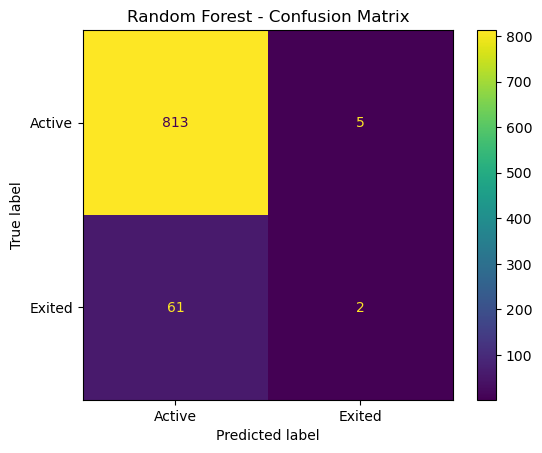

In [54]:
# ============================================================
# RANDOM FOREST CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_cm = confusion_matrix(y_test, rf_y_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Active", "Exited"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [55]:
# ============================================================
# RANDOM FOREST - METRICS


rf_accuracy = accuracy_score(y_test, rf_y_pred)

rf_precision = precision_score(
    y_test,
    rf_y_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_y_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_y_pred,
    zero_division=0
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy * 100, 2), "%")
print("Precision:", round(rf_precision * 100, 2), "%")
print("Recall   :", round(rf_recall * 100, 2), "%")
print("F1 Score :", round(rf_f1 * 100, 2), "%")

Random Forest Results
---------------------
Accuracy : 92.51 %
Precision: 28.57 %
Recall   : 3.17 %
F1 Score : 5.71 %


In [56]:
# ============================================================
# RANDOM FOREST - THRESHOLD TUNING


from sklearn.metrics import precision_score, recall_score, f1_score

rf_thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print("Random Forest Threshold Comparison")
print("=" * 75)

for threshold in rf_thresholds:

    rf_threshold_pred = (rf_y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        rf_threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        rf_threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        rf_threshold_pred,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision*100:.2f}% | "
        f"Recall: {recall*100:.2f}% | "
        f"F1: {f1*100:.2f}%"
    )

Random Forest Threshold Comparison
Threshold: 0.20 | Precision: 26.00% | Recall: 20.63% | F1: 23.01%
Threshold: 0.25 | Precision: 35.48% | Recall: 17.46% | F1: 23.40%
Threshold: 0.30 | Precision: 40.91% | Recall: 14.29% | F1: 21.18%
Threshold: 0.35 | Precision: 37.50% | Recall: 9.52% | F1: 15.19%
Threshold: 0.40 | Precision: 33.33% | Recall: 6.35% | F1: 10.67%
Threshold: 0.45 | Precision: 37.50% | Recall: 4.76% | F1: 8.45%
Threshold: 0.50 | Precision: 28.57% | Recall: 3.17% | F1: 5.71%


In [57]:
# ============================================================
# FINAL MODEL COMPARISON

model_comparison = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Balanced Logistic Regression",
        "Balanced Logistic Regression (Threshold 0.70)",
        "Random Forest"
    ],
    "Accuracy": [
        92.96,
        72.19,
        87.74,
        92.51
    ],
    "Precision": [
        66.67,
        17.27,
        25.81,
        28.57
    ],
    "Recall": [
        3.17,
        76.19,
        38.10,
        3.17
    ],
    "F1 Score": [
        6.06,
        28.15,
        30.77,
        5.71
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Original Logistic Regression,92.96,66.67,3.17,6.06
1,Balanced Logistic Regression,72.19,17.27,76.19,28.15
2,Balanced Logistic Regression (Threshold 0.70),87.74,25.81,38.10,30.77
3,Random Forest,92.51,28.57,3.17,5.71


# Final Model Selection:--->

The Balanced Logistic Regression model with a decision threshold of 0.70 was selected as the final model among the tested configurations because it achieved the highest F1 Score of 30.77%.

The original Logistic Regression and Random Forest models achieved high accuracy but very low recall, indicating that they failed to identify most employees who actually exited.

Although the balanced model at the default threshold of 0.50 achieved higher recall (76.19%), the 0.70 threshold provided the highest F1 Score (30.77%) among the tested thresholds.